# **ADULT **-** To determine whether a person's income is over $50,000 a year.**

**Name : ROHITH T U**

**Organization : ENTRI ELEVATE. **

# **Overview of the preoblem **:
This project aims to build a Machine Learning model to predict whether an individual earns more than $50K per year based on demographic and employment-related attributes such as age, education, occupation, and working hours.

**Objective:**
To build a Machine Learning model to predict whether an individual earns more than $50K per year.


Source: https://archive.ics.uci.edu/dataset/2/adult.

**Features: **
Age: Age of the individual.

Workclass: Type of employment (Private, Government, Self-employed, etc.).

Education: Highest level of education attained.

Education-num: Numeric representation of education level.

Marital-status: Marital condition of the individual.

Occupation: Job role or profession.

Relationship: Relationship status within the household.

Race: Ethnic background.

Sex: Gender of the individual.

Capital-gain: Income from investments or asset sales.

Capital-loss: Financial losses from investments.

Hours-per-week: Number of hours worked per week.

Native-country: Country of origin.

**Target Variable:**
Income: Indicates whether a person earns >50K or <=50K annually.




In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve,roc_auc_score
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib


In [2]:
df = pd.read_csv(r"/content/adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Now there is a clear picture we get from the above dataset that it consist of 32561 rows and 15 columns.


In [6]:
# finding the null values
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Null values are not present in the data set


In [7]:
# finding the duplicates
df.duplicated().sum()

np.int64(24)

In [8]:
# Removing the null values
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

The dataset consist of 24 duplicate values - drop_duplicates used to delete the duplicate value from the dataset, now the dataset is clean. After removing 24 duplicate we have 32537 rows and 15 columns.

In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


We get the disribution of numerical columns

In [10]:
df.describe(include='object')

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32537,32537,32537,32537,32537,32537,32537,32537,32537
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22673,10494,14970,4136,13187,27795,21775,29153,24698


No we get the distribution of categorical values.

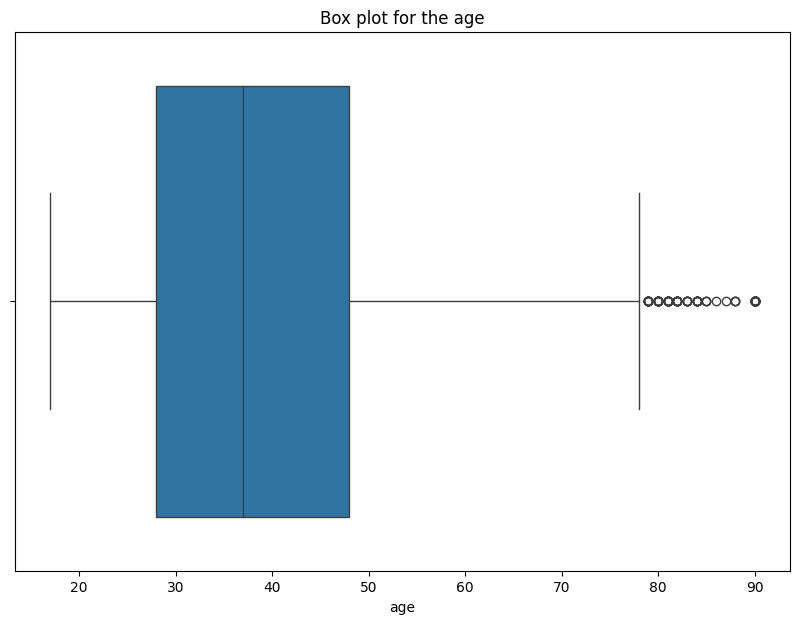

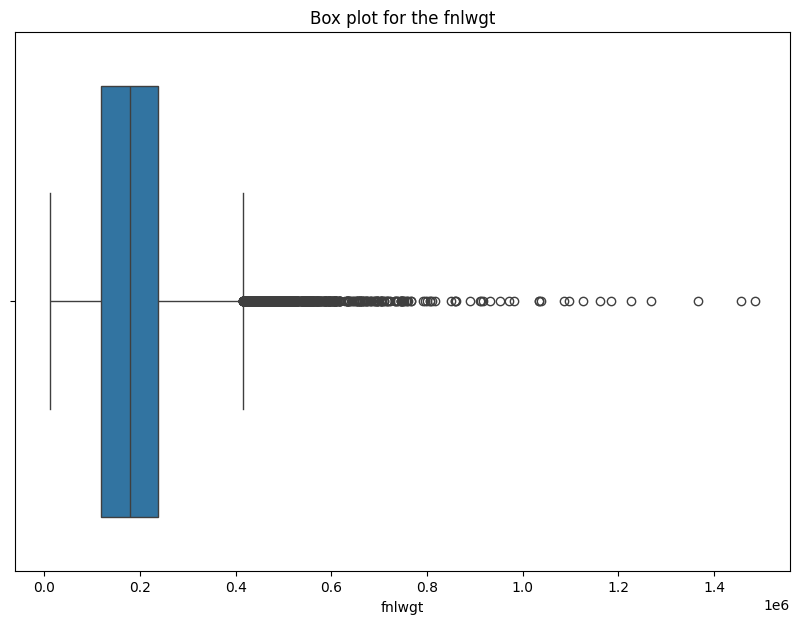

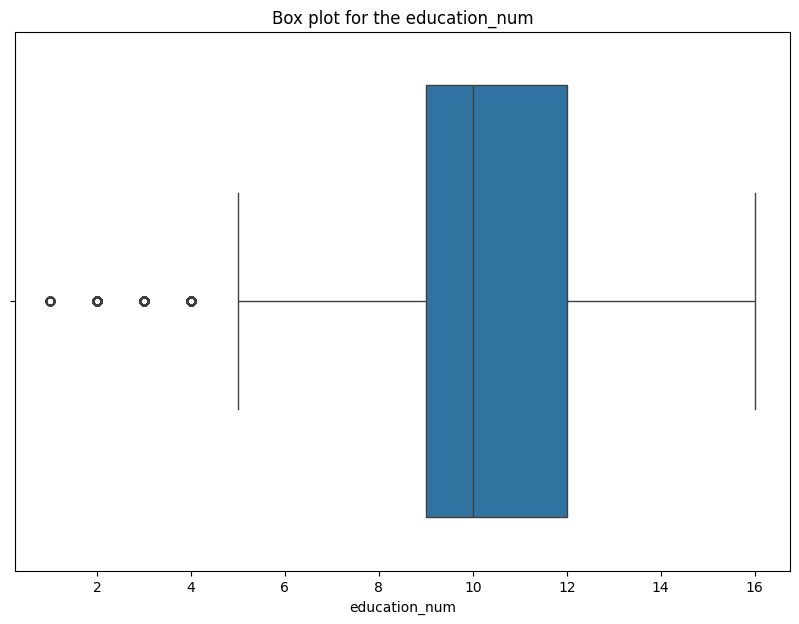

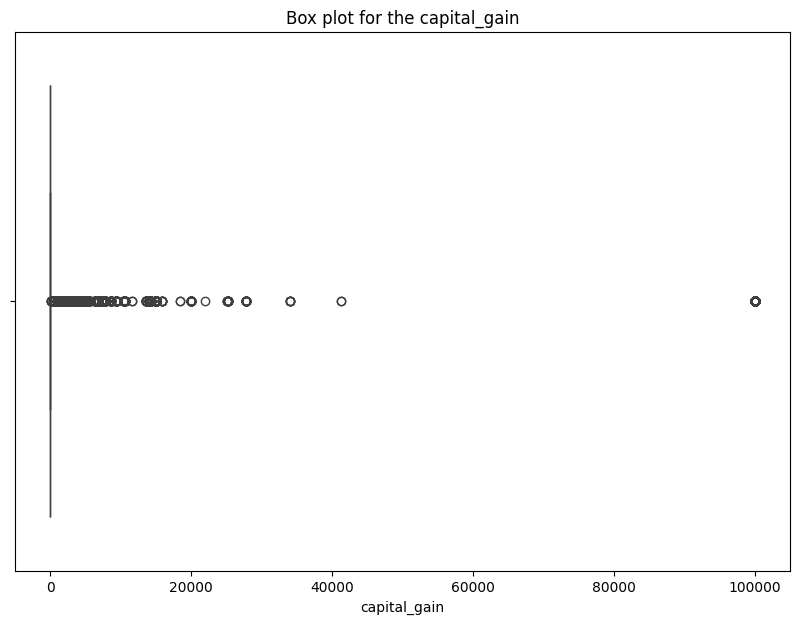

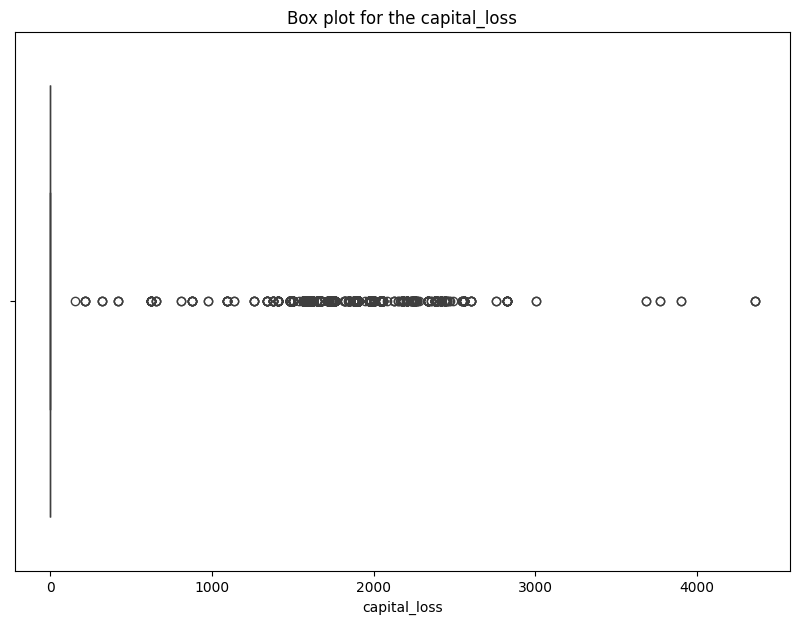

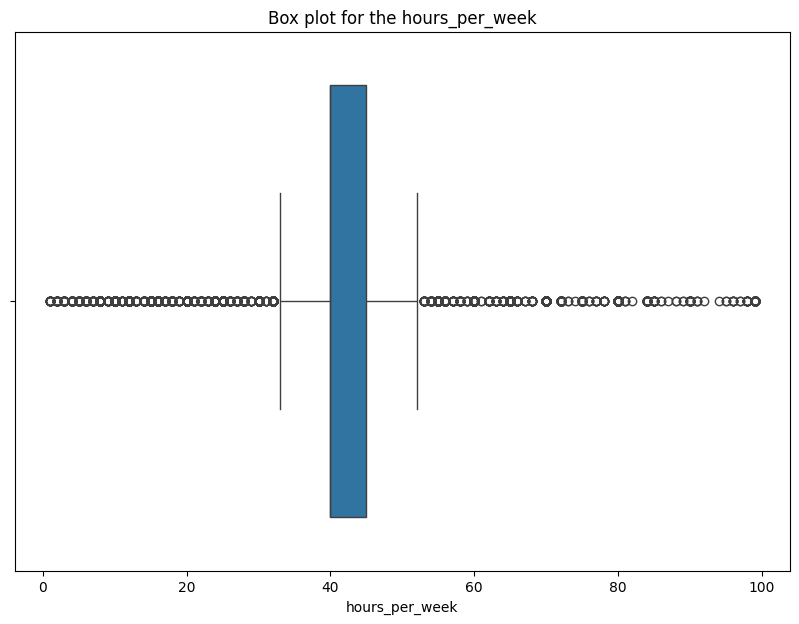

In [11]:
# finding out the outliers
num_col = df.select_dtypes(include=[int,float]).columns

for col in num_col:
  plt.figure(figsize=(10,7))
  sns.boxplot(x=df[col])
  plt.title(f"Box plot for the {col}")
  plt.show()

From the Boxplot we get the existing outliers from the data. But before removing these outliers we need to understand the distribution of data by ploting the Histogram.

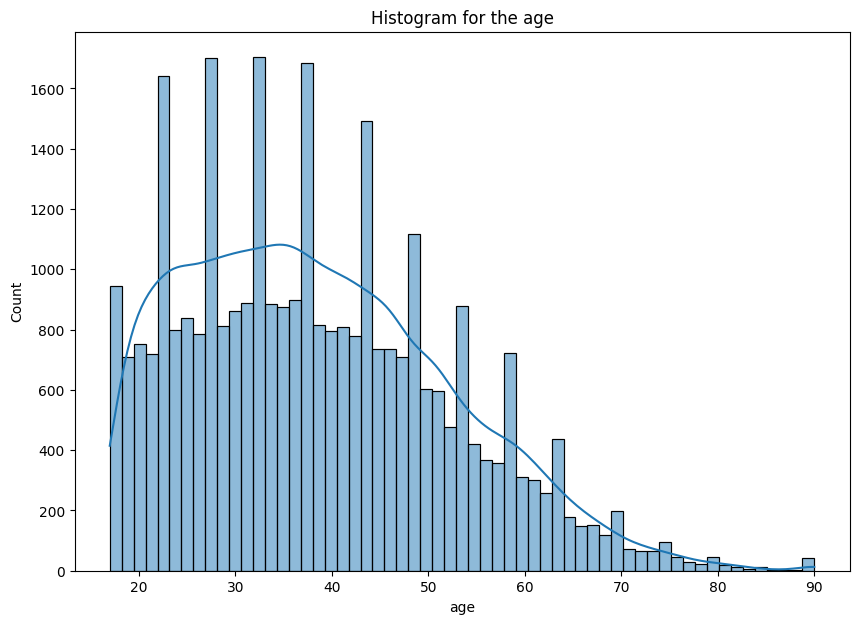

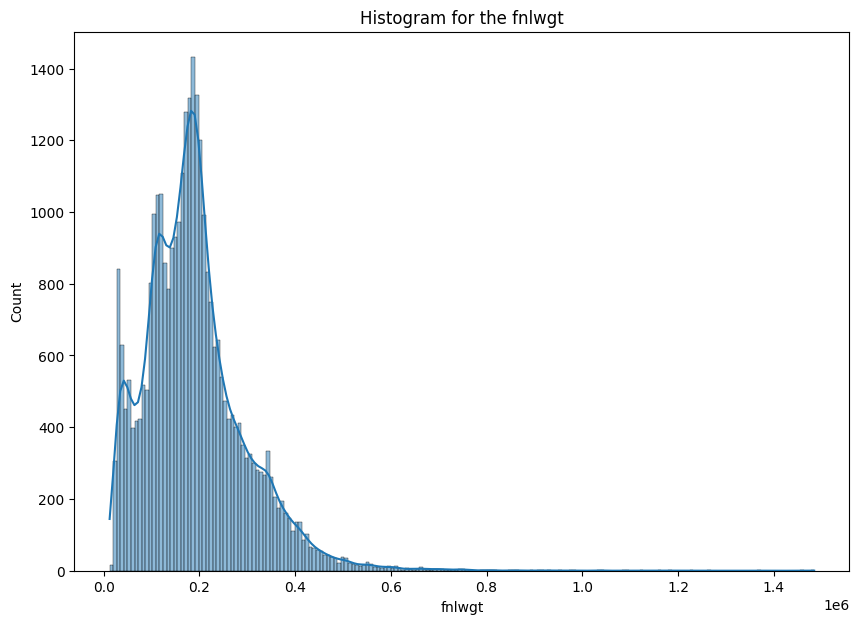

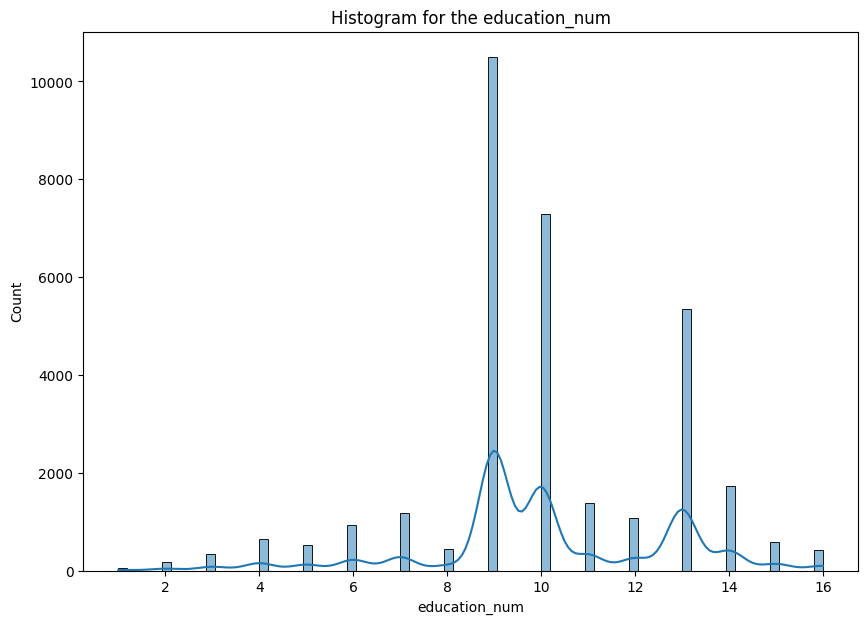

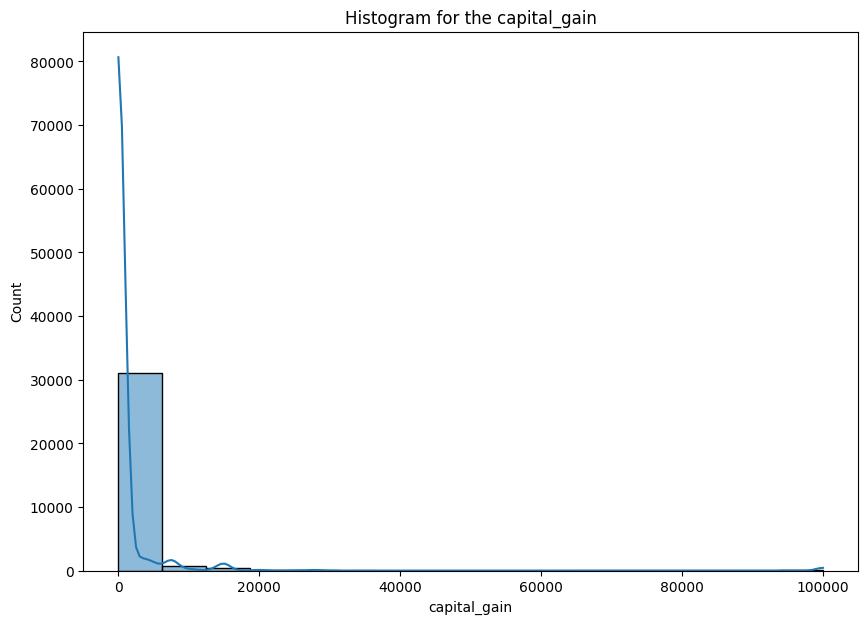

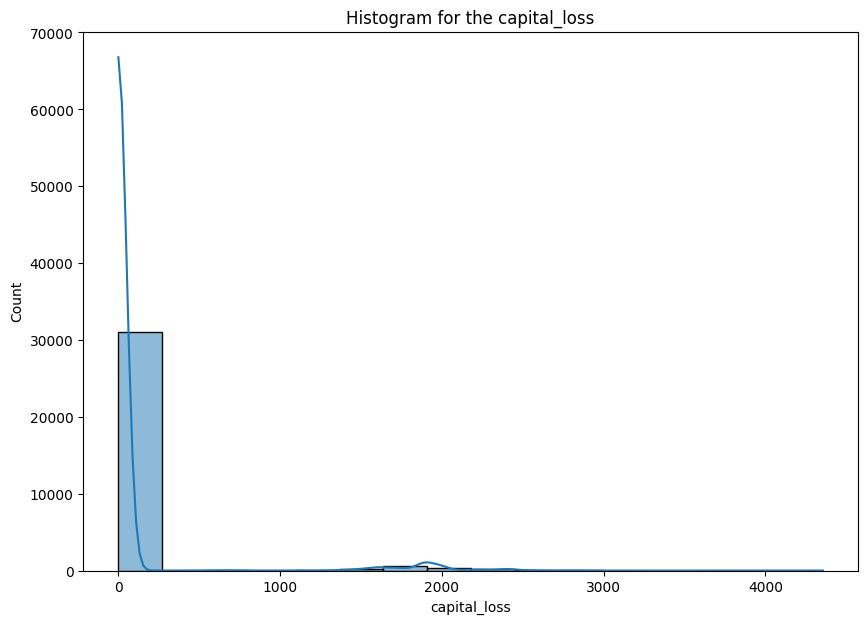

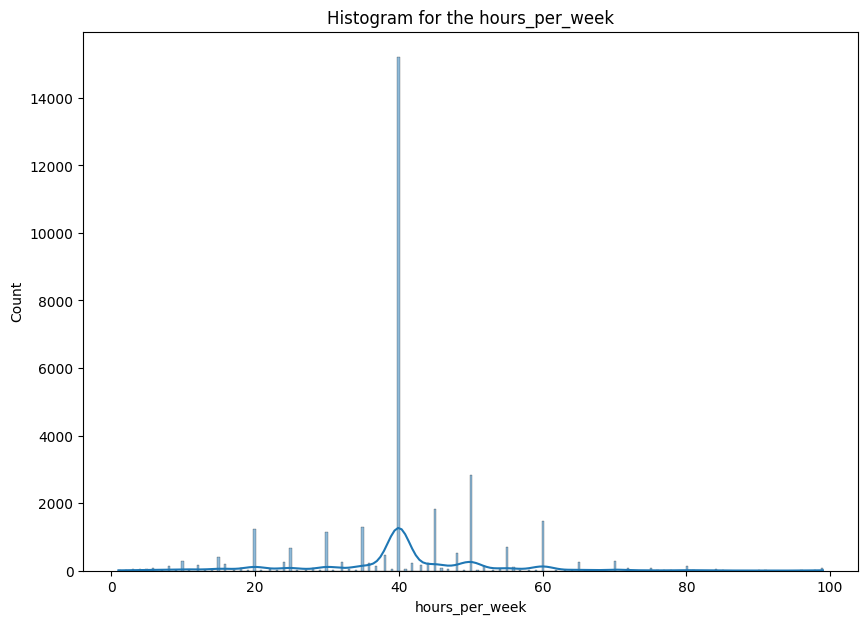

In [12]:
# Histogarm
for col in num_col:
  plt.figure(figsize=(10,7))
  sns.histplot(x=df[col],kde=True)
  plt.title(f"Histogram for the {col}")
  plt.show()

The **education_num** features shows a bimodel distribution, there is 2 peaks one is individuals who completed high schools and other is individuals who completed college. This is a strong feature.

**Captital_gain** and **Capital_loss** bold text are right skewed features we need to treat them but we are not removing outliers because of that is income so it can be more or less.

**hour_per_week** feature shows a normal distribution centered arounf 40 hours indicating that most of individuals works standard full-time. a few higher values suggest the presence of heavy workload groups who doing over tim w works. No need to do any treatment.

**Age** feature shows a normal but slightly right skewed distribution and prime working age around between 25-50. Extreme ages are minimal and logically valid. No outlier treatment is required.


In [13]:
# Checking the skewness of the data
df.skew(numeric_only=True).sort_values(ascending=False)

,0
capital_gain,11.949403
capital_loss,4.592702
fnlwgt,1.447703
age,0.557663
hours_per_week,0.228759
education_num,-0.309500


Two columns like **capital_gain & capital_loss** showing high skewness so we need to transform the skewed columns.

**fnlwgt** is showing a small skewness but we remobing the column because it is just a weight.


In [14]:
# deleting the column fnlwgt
df.drop('fnlwgt',axis=1,inplace=True)

In [15]:
number_cols = df.select_dtypes(include=[int,float]).columns
number_cols

Index(['age', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [16]:
# Transorming the skewed columns

df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])


In [17]:
# checking the data after the transformation
df[['capital_gain','capital_loss']].skew()

,0
capital_gain,3.094667
capital_loss,4.305701


After the lo1p() the skewness is reduced so we are keeping the skewness because it is a income so there will be more gain also 0 loss will be there.

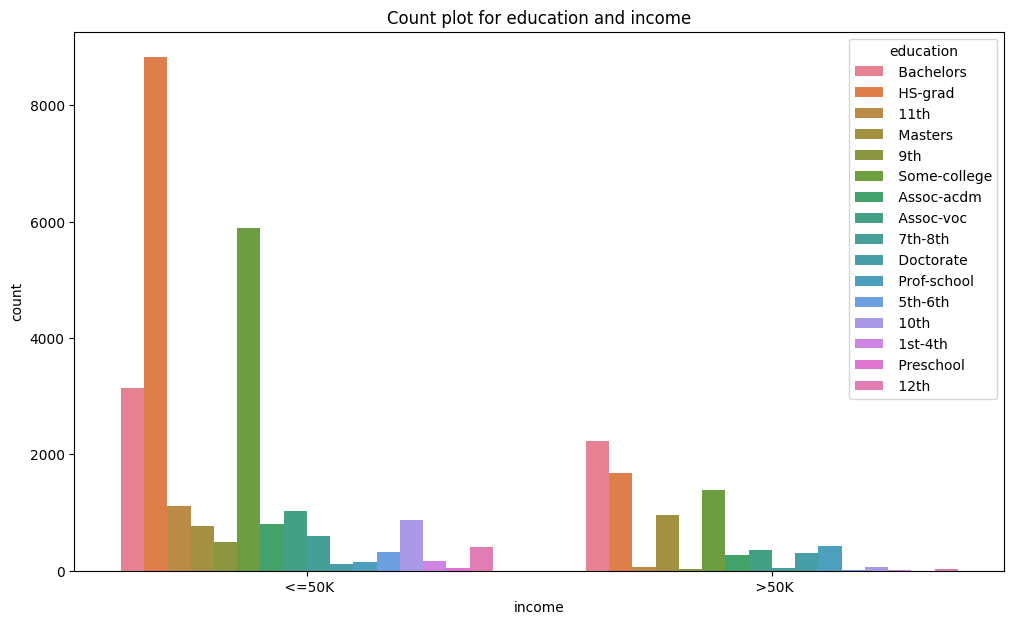

In [18]:
# plots to understand the relation between categorical values and target
# count plot
plt.figure(figsize=(12,7))
sns.countplot(x="income", hue='education', data=df)
plt.title("Count plot for education and income")
plt.show()


The count plot shows the HS-grad and Bachelors are more in both group and also others are in >=50 group that means education is not an only criteria for getting higher income. The reason for bachelors and Hs-grad because most of the individual in the data set are who completed bachelors and Hs-grad.

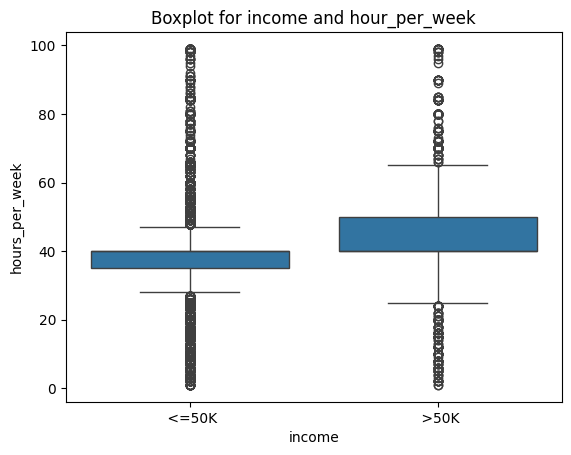

In [19]:
# box plot for comparing average
sns.boxplot(x="income",y='hours_per_week',data=df)
plt.title("Boxplot for income and hour_per_week")
plt.show()

For the plot of income vs hours_per_week shows there is no overlap between high income group and low income group.There is perfect sepration.It is strong predictor.

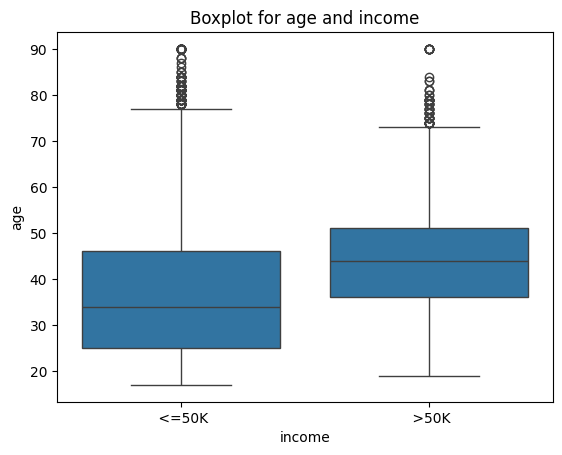

In [20]:
sns.boxplot(x='income',y='age',data=df)
plt.title('Boxplot for age and income')
plt.show()

The boxplot give the insight that spread of the high earning people are starting from 35 to 55 means they are very tight range to get that salary individuls need proper experience.
Also people <=50 less than 50 vary from 25 to 45 means low income people are exist from different age groups.
And median is higher for the group >=50.

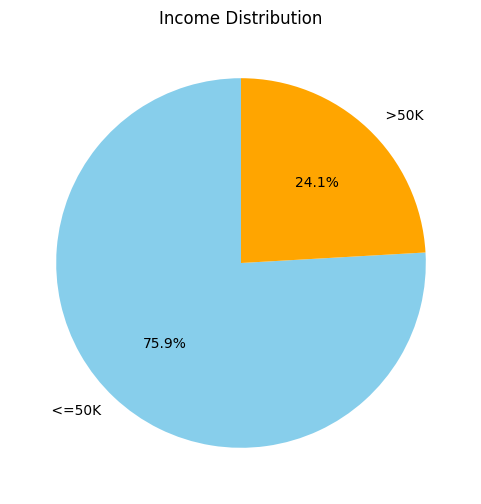

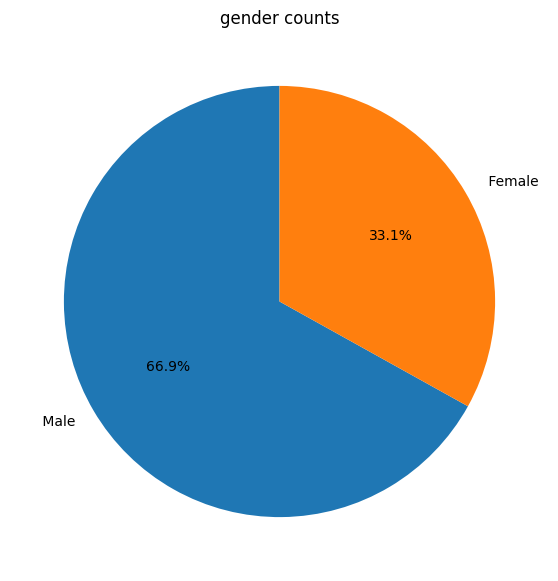

In [21]:
# pie plot income distribution

income_counts = df['income'].value_counts()
gender_counts = df['sex'].value_counts()


plt.figure(figsize=(6,6))
plt.pie(income_counts,labels=income_counts.index,autopct='%1.1f%%',startangle=90,colors=['skyblue','orange'])
plt.title('Income Distribution')
plt.show()

plt.figure(figsize=(7,7))
plt.pie(gender_counts,labels = gender_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('gender counts')
plt.show()

From Income distribution the dominant group is <=50k 75.9%.This indicates an imbalanced target distribution.


Also from gender distribution there is dominant group of male.

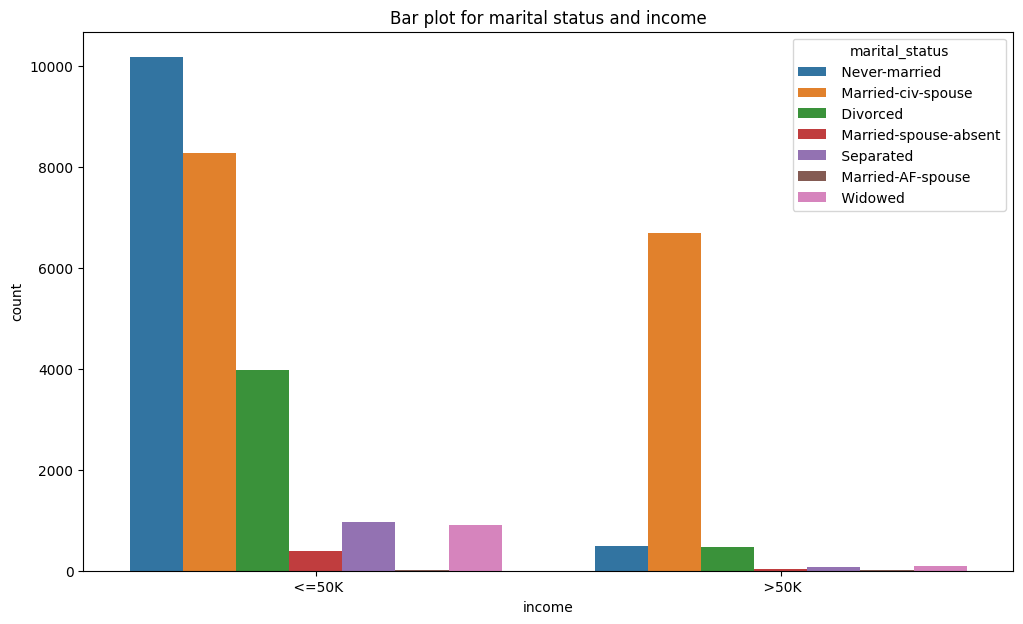

In [22]:
# bar plot for maritial status
plt.figure(figsize=(12,7))
sns.countplot(x='income',hue='marital_status',data=df)
plt.title('Bar plot for marital status and income')
plt.show()

From the both group the dominent group is married-civ-spouse.Never married group are higher in >=50k group because the people who will below 30 and 25 are there that we see in the boxplot for age.

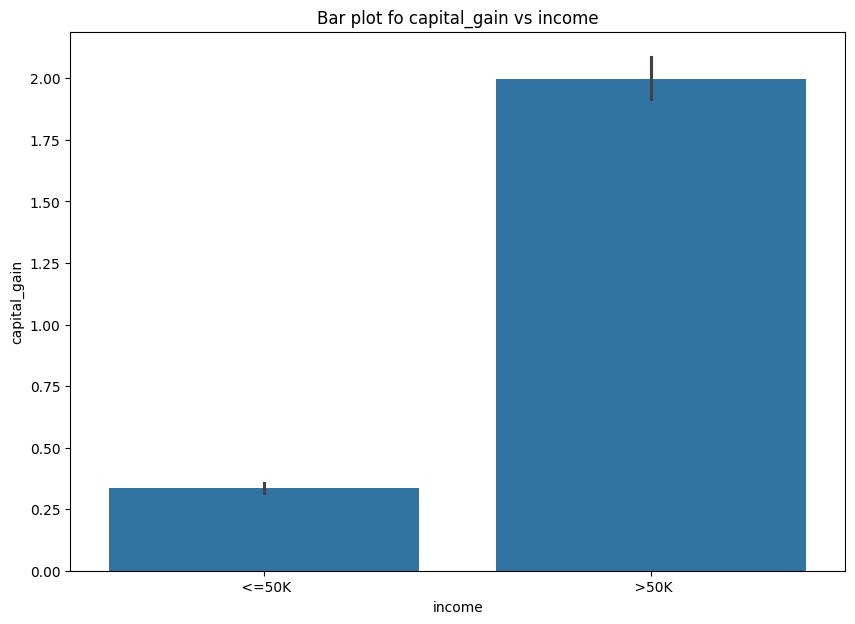

In [23]:
# Bar plot of capital_gain vs income
plt.figure(figsize=(10,7))
sns.barplot(x='income',y='capital_gain',data=df)
plt.title("Bar plot fo capital_gain vs income")
plt.show()

Individuals who earning salary >=50k having higher capital gain and individuals who earning <=50k having less capital gain.

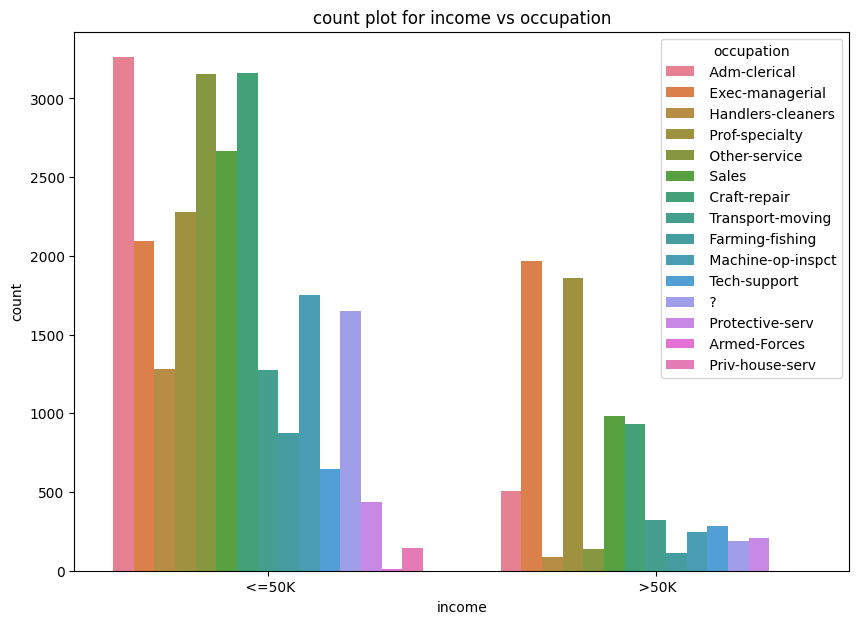

In [24]:
# count plot of occupation vs income
plt.figure(figsize=(10,7))
sns.countplot(x='income',hue='occupation',data=df)
plt.title("count plot for income vs occupation")
plt.show()

According to this count plot occupation alone coonot predict earning potential.For example: for the managerial job the count is almost same for each group. That means postion, experinece and type of field also depends.


*   Now we understood the distributions.
*   Found outliers and transform it.
*   Seen categorical relationship.

Next we need to check which numerical feature influence target column for that we need heatmap.









In [25]:
# income column contains a space before (<=) this sign so i find out the space and that same space is appied at the time of converting it into numeric.
df['income'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [26]:
# before heat map need to convert target categorical column to numeric
df['income']=df['income'].map({' <=50K':0,' >50K':1})

In [27]:
df

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40,United-States,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40,United-States,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0.000000,0.0,38,United-States,0
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.000000,0.0,40,United-States,1
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0.000000,0.0,40,United-States,0
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0.000000,0.0,20,United-States,0


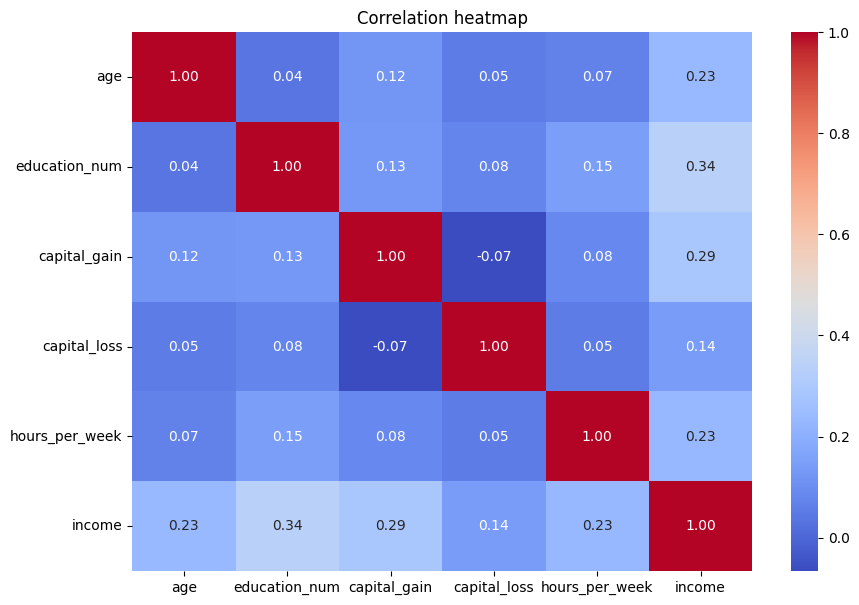

In [28]:
# heatmap

num_df = df.select_dtypes(include=[int,float])

plt.figure(figsize=(10,7))
sns.heatmap(num_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation heatmap")
plt.show()

The heat indicates that education_num,capital_gain,age,hours_per_week shows positive correlation with income.

In [29]:
# converting the categorical values to numeric by using one hot encoding

cat_col = df.select_dtypes(include=[object]).columns

df = pd.get_dummies(df,columns=cat_col,drop_first=True,dtype=int)


In [30]:
df

,age,education_num,capital_gain,capital_loss,hours_per_week,income,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
0,39,13,7.684784,0.0,40,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,13,0.000000,0.0,13,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,9,0.000000,0.0,40,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,7,0.000000,0.0,40,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0.000000,0.0,40,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,0.000000,0.0,38,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32557,40,9,0.000000,0.0,40,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32558,58,9,0.000000,0.0,40,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32559,22,9,0.000000,0.0,20,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [31]:
# separate feature and target
x = df.drop('income',axis=1)
y=df['income']

# split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42) # 20% test, 80% train

In [32]:
# Feature selection

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train,y_train)

# get feature importance
feat_importance = pd.Series(rf.feature_importances_,index=x_train.columns)

feat_importance = feat_importance.sort_values(ascending=False)


In [33]:
feat_importance.head(20)

,0
age,0.235310
hours_per_week,0.115264
capital_gain,0.103365
marital_status_ Married-civ-spouse,0.079492
education_num,0.068236
capital_loss,0.034893
marital_status_ Never-married,0.031084
sex_ Male,0.023176
occupation_ Exec-managerial,0.019437
relationship_ Not-in-family,0.019411


After the feature selection we are only taking 20 because the values are very close to 0 so if take more that will be very close to 0 it will make our data noisy. so dropping them can make the model faster and less likely to overfit

In [34]:
# save the top features
top_features = feat_importance.head(20).index

x_train_selected = x_train[top_features]
x_test_selected = x_test[top_features]

Now the x_train and x_test contain the selected 20 features only other we dropped.


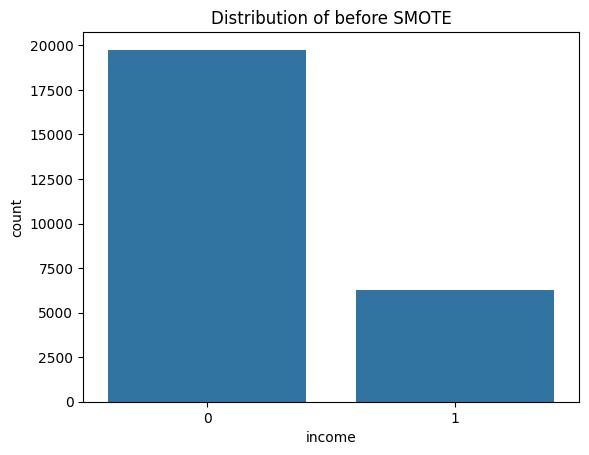

In [35]:
sns.countplot(x=y_train)
plt.title("Distribution of before SMOTE")
plt.show()

In [36]:
# Applying SMOTE- x_train_selected,y_train

smote = SMOTE(random_state=42)

x_train_res,y_train_res = smote.fit_resample(x_train_selected,y_train)



Training set is balanced now.

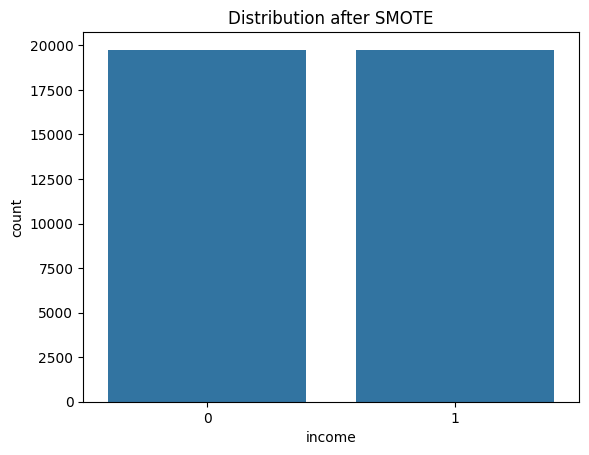

In [37]:
# count plot after SMOTE
sns.countplot(x=y_train_res)
plt.title("Distribution after SMOTE")
plt.show()

In [38]:
# scele the numeric data using standardscaler and columntransformer
number_cols # these are the numeric columns we already took at the first

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),number_cols)
    ],
    remainder='passthrough'
)

In [39]:
x_train_processed = preprocessor.fit_transform(x_train_res)
x_test_processed = preprocessor.transform(x_test_selected)

The scaling process is completed, now we need to change this bavck to dataframe, because now it is numpy.

In [40]:
# convert back t0 datafram from numpy
x_train_processed = pd.DataFrame(
    x_train_processed,
    columns=preprocessor.get_feature_names_out()
)

x_test_processed = pd.DataFrame(
    x_test_processed,
    columns=preprocessor.get_feature_names_out()
)

Numpy is converted back to DataFrame

In [41]:
# Create a model dictionary
models = {
    'LogisticRegression':LogisticRegression(max_iter=100),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'svm':SVC(),
    'KNN':KNeighborsClassifier()
}

In [42]:

result=[]

for name,model in models.items():
  #Train
  model.fit(x_train_processed,y_train_res)

  # Predict
  y_pred = model.predict(x_test_processed)

 # calculate metrics
  acc = accuracy_score(y_test,y_pred)
  prec = precision_score(y_test,y_pred)
  rec = recall_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)

  result.append([name,acc,prec,rec,f1])


In [43]:
result_df = pd.DataFrame(result,columns=['Model','Accuracy','precision','Recall','F1_score'])
result_df

,Model,Accuracy,precision,Recall,F1_score
0,LogisticRegression,0.790412,0.542114,0.837372,0.658145
1,RandomForestClassifier,0.821911,0.608834,0.729592,0.663766
2,GradientBoostingClassifier,0.822219,0.591374,0.848214,0.696882
3,svm,0.803319,0.560708,0.848214,0.675127
4,KNN,0.808543,0.582904,0.721939,0.645014


In [44]:
result_df.sort_values(by='F1_score',ascending=False)

,Model,Accuracy,precision,Recall,F1_score
2,GradientBoostingClassifier,0.822219,0.591374,0.848214,0.696882
3,svm,0.803319,0.560708,0.848214,0.675127
1,RandomForestClassifier,0.821911,0.608834,0.729592,0.663766
0,LogisticRegression,0.790412,0.542114,0.837372,0.658145
4,KNN,0.808543,0.582904,0.721939,0.645014


Here we sort the f1 score and we get gradientboostingclassifier as the best model.

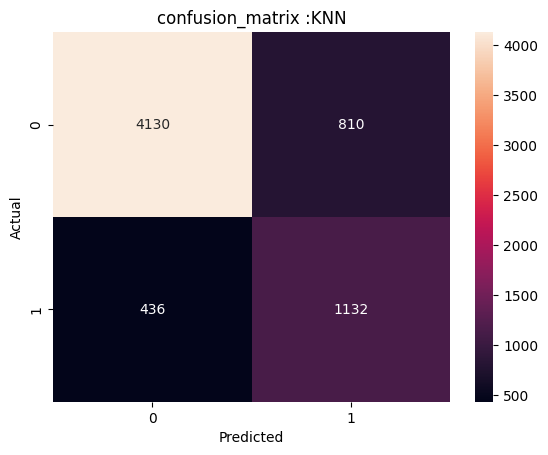

In [45]:
# confusion matrix
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title(f"confusion_matrix :{name}")
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.show()

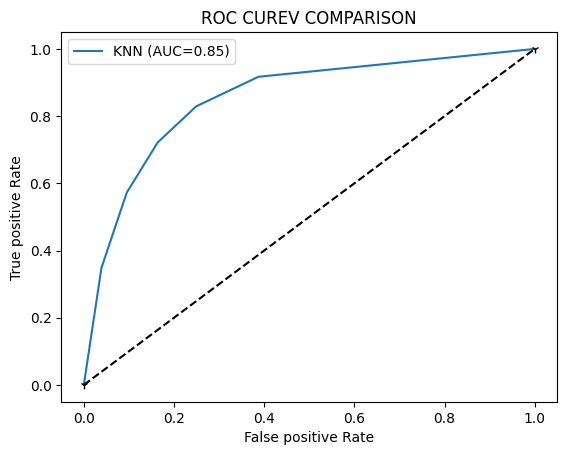

In [46]:
# roc curev and roc_auc_score
if hasattr(model,"predict_proba"):
  y_prob = model.predict_proba(x_test_processed)[:,1]
else:
  y_prob = model.decision_function(x_test_processed)

fpr,tpr,_ = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f"{name} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1],'k--1')
plt.xlabel("False positive Rate")
plt.ylabel("True positive Rate")
plt.title("ROC CUREV COMPARISON")
plt.legend()
plt.show()


In [47]:
param_grids = {
    "LogisticRegression":{
        "model__C":[0.1,1,10]
    },
    "RandomForestClassifier":{
        "model__n_estimators":[100,200,300],
        "model__max_depth": [None,10]
    },
    "svm":{
        "model__C":[0.1,1],
        "model__kernel":["linear","rbf"]
    },
    "KNN":{
        "model__n_neighbors":[3,5,7]
    },
    "GradientBoostingClassifier":{
        "model__n_estimators":[100,200],
        "model__learning_rate":[0.01,0.1]
    }
}

For hyperparameter tuning we defined the models.

In [48]:
best_model = {}
results = []

for name in models:
  print(f"Tuning {name}...")

  pipeline = Pipeline([
      ("smote",SMOTE(random_state=42)),
      ("preprocessor",preprocessor),
      ('model',models[name])
  ])

  grid = GridSearchCV(
      pipeline,
      param_grids[name],
      cv=3,
      scoring='f1',
      n_jobs=-1
  )
  grid.fit(x_train,y_train)

  best_model[name] =grid.best_estimator_


  y_pred = grid.best_estimator_.predict(x_test)
  f1 = f1_score(y_test,y_pred)

  results.append([name,f1])

  print("Best params:",grid.best_params_)
  print("Test f1:",f1)

Tuning LogisticRegression...
Best params: {'model__C': 0.1}
Test f1: 0.6699140401146132
Tuning RandomForestClassifier...
Best params: {'model__max_depth': 10, 'model__n_estimators': 200}
Test f1: 0.6838326318395642
Tuning GradientBoostingClassifier...
Best params: {'model__learning_rate': 0.1, 'model__n_estimators': 200}
Test f1: 0.7139626907857547
Tuning svm...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__C': 1, 'model__kernel': 'rbf'}
Test f1: 0.6995810891681628
Tuning KNN...
Best params: {'model__n_neighbors': 7}
Test f1: 0.6435778565584946


In [49]:
results_df = pd.DataFrame(results,columns=["Model","Test F1 Score"])
results_df = results_df.sort_values(by="Test F1 Score",ascending=False)

results_df

,Model,Test F1 Score
2,GradientBoostingClassifier,0.713963
3,svm,0.699581
1,RandomForestClassifier,0.683833
0,LogisticRegression,0.669914
4,KNN,0.643578


Ater tuning according to f1 score gradientboostingclassifier is the best model and the f1 score is also increased.

In [50]:
# save the best model
best_model_name = results_df.iloc[0]["Model"]
final_model = best_model[best_model_name]

joblib.dump(final_model,"best_income_model.pkl")

print("Saved model:",best_model_name)


Saved model: GradientBoostingClassifier


In [51]:
# load and test on unseen data
loaded_model = joblib.load("best_income_model.pkl")

y_pred_unseen = loaded_model.predict(x_test)

In [52]:
print(y_pred_unseen[:10])

[0 1 0 0 0 0 0 0 0 0]


In [53]:
# compare it with actual
print(y_test[:10])


20334    0
23878    1
19996    0
21440    0
10000    0
16397    0
3400     0
8484     0
2823     0
7275     1
Name: income, dtype: int64


In [54]:
print("Accuracy:",accuracy_score(y_test,y_pred_unseen))
print("F1 Score:",f1_score(y_test,y_pred_unseen))


Accuracy: 0.844499078057775
F1 Score: 0.7139626907857547


For the unseen data we get the accuracy of 84% and f1 score of 71%.

# In this project, a machine learning model was developed to predict whether a person's income is greater than or less than $50K using the Adult Dataset.

Initially, EDA(Exploratory Data Analysis) was performed to understand the distribution of variables and identify the patterns in the dataset. Histogram,Boxplot,countplot,piechart, Heatmap were used to explore relationship between features and target variable.

Some insights are:

*   The age distribution showed that most of the individuals falls within the age of 20-50 age range.
*   The hours_per_week feature followed a bell shaped curve with a peak around 40 hours.
*  Higher educated individuals earn more than 50K.
*   Certian occupation such as managerial and professional job are paying higher salary.

Data modeling:


* Categorical variables were converted using One-Hot Encoding.
* Skewed numerical features such as capital_gain and capital_loss were transformed using logarithmic transformation.
* Class imbalance in the target variable was handled using the SMOTE technique.
* Numerical features were standardized using StandardScaler.

Multiple machine learning models were trained and evaluated, including:

*   Logistic Regression.
*   Random Forest.
*   GradientBoosting.
*   SVM.
*   KNN.

Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics.

Among all models, the Gradient Boosting model achieved the best overall performance with the highest F1-score, indicating a good balance between precision and recall for predicting high-income individuals.

Hyperparameter tuning was performed using GridSearchCV to further optimize model performance. The best-performing model was then saved and tested on unseen data.

The final model demonstrated strong predictive capability and can effectively classify individuals into income categories based on demographic and work-related features.

Overall, this project demonstrates how data preprocessing, feature engineering, class balancing, and model tuning can significantly improve machine learning model performance in real-world classification problems.
